In [1]:
import pandas as pd
import helpers
pd.set_option('display.max_columns', None)

In [2]:
url = "https://www.basketball-reference.com/players/q/"
helpers.request_and_save(url, "scrape_q_names.html")


<!DOCTYPE html>

<html class="no-js" data-root="/home/bbr/build" data-version="klecko-" lang="en">
<head>
<meta charset="utf-8"/>
<meta content="ie=edge" http-equiv="x-ua-compatible"/>
<meta content="width=device-width, initial-scale=1.0, maximum-scale=2.0" name="viewport">
<link href="https://cdn.ssref.net/req/202512181" rel="dns-prefetch"/>
<script>
/* https://docs.osano.com/hc/en-us/articles/22469433444372-Google-Consent-Mode-v2  */
  window.dataLayer = window.dataLayer ||[];
      function gtag(){dataLayer.push(arguments);}
      gtag('consent','default',{
        'ad_storage':'denied',
        'analytics_storage':'denied',
        'ad_user_data':'denied',
        'ad_personalization':'denied',
        'personalization_storage':'denied',
        'functionality_storage':'granted',
        'security_storage':'granted',
        'wait_for_update': 500
      });
      gtag("set", "ads_data_redaction", true);
</script>
<script src="https://cmp.osano.com/16CGnCU8UtNhM14sg/12669873-8cf8-4
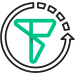
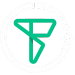

In [3]:
soup = helpers.create_parse("scrape_q_names.html")
soup

In [4]:
players = soup.select_one('tbody').select('tr')
players

[<tr><th class="left" data-append-csv="qizh01" data-stat="player" scope="row"><a href="/players/q/qizh01.html">Zhou Qi</a></th><td class="right" data-stat="year_min">2018</td><td class="right" data-stat="year_max">2019</td><td class="center" data-stat="pos">F-C</td><td class="right" csk="85.0" data-stat="height">7-1</td><td class="right" data-stat="weight">210</td><td class="left" csk="19960116" data-stat="birth_date"><a href="/friv/birthdays.cgi?month=1&amp;day=16">January 16, 1996</a></td><td class="left iz" data-stat="colleges"></td></tr>,
 <tr><th class="left" data-append-csv="quartti01" data-stat="player" scope="row"><a href="/players/q/quartti01.html">Tim Quarterman</a></th><td class="right" data-stat="year_min">2017</td><td class="right" data-stat="year_max">2018</td><td class="center" data-stat="pos">G</td><td class="right" csk="78.0" data-stat="height">6-6</td><td class="right" data-stat="weight">190</td><td class="left" csk="19941027" data-stat="birth_date"><a href="/friv/bir

In [5]:
links = []
names = []
for player in players:
    if player.select_one('strong') is not None:
        name = player.select_one('th').get_text()
        link = player.select_one('th a')['href']
        print(name, 'https://www.basketball-reference.com/' +link)
        names.append(name)
        links.append('https://www.basketball-reference.com/' +link)

Derik Queen https://www.basketball-reference.com//players/q/queende01.html
Trevelin Queen https://www.basketball-reference.com//players/q/queentr01.html
Neemias Queta https://www.basketball-reference.com//players/q/quetane01.html
Immanuel Quickley https://www.basketball-reference.com//players/q/quickim01.html
Lester Quiñones https://www.basketball-reference.com//players/q/quinole01.html


In [6]:
"Derik Queen".replace(" ", "_")

'Derik_Queen'

In [7]:
import os
from time import sleep
os.makedirs('q_pages', exist_ok=True)
for player, link in zip(names, links):
    if os.path.exists(f"q_pages/{player.replace(' ', '_')}.html"):
        print(f"Already have {player}, skipping")
        continue
    else:
        print(f"Fetching {player}")
        helpers.request_and_save(link, f"q_pages/{player.replace(' ', '_')}.html")
        sleep(10)

Already have Derik Queen, skipping
Already have Trevelin Queen, skipping
Already have Neemias Queta, skipping
Already have Immanuel Quickley, skipping
Already have Lester Quiñones, skipping


In [8]:
transaction_tables = []
for name in names:
    print(name)
    transaction_tables.append(helpers.transactions_table(helpers.create_parse(f"q_pages/{name.replace(' ', '_')}.html")))

Derik Queen
July 6, 2022
June 25, 2025
June 25, 2025
July 5, 2025
Trevelin Queen
November 30, 2020
December 16, 2020
September 29, 2021
October 15, 2021
December 18, 2021
July 1, 2022
October 9, 2022
October 11, 2022
March 29, 2023
September 12, 2023
October 21, 2023
July 5, 2024
Neemias Queta
July 29, 2021
August 8, 2021
July 2, 2022
August 8, 2023
September 12, 2023
September 17, 2023
April 8, 2024
July 6, 2024
Immanuel Quickley
July 8, 2019
November 18, 2020
November 20, 2020
November 28, 2020
December 30, 2023
July 8, 2024
Lester Quiñones
July 5, 2022
October 13, 2022
March 2, 2023
March 17, 2023
July 22, 2023
February 22, 2024
September 26, 2024
December 3, 2024
March 2, 2025
July 24, 2025
September 2, 2025
October 18, 2025


In [12]:
print(names[0])
transaction_tables[0]

Derik Queen


,Date,Event,New Team,Supplementary Info,next
0,"July 6, 2022",Traded,Atlanta Hawks,with Maurice Harkless and Justin Holidayfor Ke...,1.0
1,"June 25, 2025",Drafted,Atlanta Hawks,1st round (13th pick) of the 2025 NBA Draft.,2.0
2,"June 25, 2025",Traded,New Orleans Pelicans,for Asa Newell and a 2026 1st round draft pick...,NaN


In [13]:
print(names[1])
transaction_tables[1]

Trevelin Queen


,Date,Event,New Team,Supplementary Info,next
0,"November 30, 2020",Signed,Houston Rockets,None,1.0
1,"December 16, 2020",Waived,None,None,2.0
2,"September 29, 2021",Signed,Los Angeles Lakers,None,3.0
3,"October 15, 2021",Waived,None,None,4.0
4,"December 18, 2021",Signed,Houston Rockets,None,5.0
5,"July 1, 2022",Signed,Philadelphia 76ers,None,6.0
6,"October 9, 2022",Waived,None,None,7.0
7,"October 11, 2022",Signed,Indiana Pacers,None,8.0
8,"March 29, 2023",Waived,None,None,9.0
9,"September 12, 2023",Signed,Orlando Magic,None,NaN


In [14]:
print(names[2])
transaction_tables[2]

Neemias Queta


,Date,Event,New Team,Supplementary Info,next
0,"July 29, 2021",Drafted,Sacramento Kings,2nd round (39th pick) of the 2021 NBA Draft.,1.0
1,"September 12, 2023",Waived,None,None,2.0
2,"September 17, 2023",Signed,Boston Celtics,None,NaN


In [15]:
print(names[3])
transaction_tables[3]

Immanuel Quickley


,Date,Event,New Team,Supplementary Info,next
0,"July 8, 2019",Traded,Oklahoma City Thunder,for Jerami Grant. (top-10 protected),1.0
1,"November 18, 2020",Drafted,Oklahoma City Thunder,1st round (25th pick) of the 2020 NBA Draft.,2.0
2,"November 20, 2020",Traded,New York Knicks,None,3.0
3,"December 30, 2023",Traded,Toronto Raptors,with R.J. Barrett and a 2024 2nd round draft p...,NaN


In [16]:
print(names[4])
transaction_tables[4]

Lester Quiñones


,Date,Event,New Team,Supplementary Info,next
0,"July 5, 2022",Signed,Golden State Warriors,None,1.0
1,"October 13, 2022",Waived,None,None,2.0
2,"September 26, 2024",Signed,Philadelphia 76ers,None,3.0
3,"December 3, 2024",Waived,None,None,4.0
4,"March 2, 2025",Signed,New Orleans Pelicans,None,5.0
5,"July 24, 2025",Waived,None,None,6.0
6,"September 2, 2025",Signed,Orlando Magic,None,7.0
7,"October 18, 2025",Waived,None,None,NaN
